# P2 — Exploratory analysis

Every plot here should either kill or justify a candidate feature for P5. The gate is the
hypothesis table at the end, not the figure count.

**Invariant:** all analysis in this notebook is computed on `d_1`-`d_1913` only. Plotting the
`d_1914`-`d_1941` holdout is a subtle form of peeking - it would shape feature choices around data
we've promised not to use. The load step below filters to the training range at read time so the
holdout is never materialized in this notebook at all.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import MSTL

DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = Path("..") / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = 1913  # d_1914-d_1941 is the holdout (invariant 1).

sns.set_theme(style="whitegrid")

## Load: sales_long.parquet, training range only

`sales_long.parquet` spans the full calendar (`d_1`-`d_1941`) - P1 only dropped pre-release rows,
not the `d_1914`-`d_1941` holdout. Filter to `d <= TRAIN_END` at read time via pyarrow predicate
pushdown, so the holdout rows are never read off disk into this notebook, rather than loading the
full frame and filtering after (which is exactly the mistake fixed in P1's negative-sales and
sparsity checks).

In [2]:
sales_long = pd.read_parquet(
    PROCESSED_DIR / "sales_long.parquet",
    filters=[("d", "<=", TRAIN_END)],
)

assert sales_long["d"].max() <= TRAIN_END, \
    f"holdout leaked into the loaded frame: max d = {sales_long['d'].max()}"

n_unique_dates = sales_long["date"].nunique()
assert n_unique_dates == TRAIN_END, \
    f"expected {TRAIN_END} unique dates, got {n_unique_dates}"

print(f"loaded: {len(sales_long):,} rows, {sales_long.shape[1]} columns")
print(f"date range: {sales_long['date'].min().date()} to {sales_long['date'].max().date()}")
print(f"unique dates: {n_unique_dates:,}")
print(f"memory usage: {sales_long.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
sales_long.dtypes

loaded: 46,027,957 rows, 22 columns


date range: 2011-01-29 to 2016-04-24
unique dates: 1,913
memory usage: 1,753.0 MB


id                    category
item_id               category
dept_id               category
cat_id                category
store_id              category
state_id              category
sales                    int16
date            datetime64[ns]
wm_yr_wk                 int16
weekday               category
wday                      int8
month                     int8
year                     int16
d                        int16
event_name_1          category
event_type_1          category
event_name_2          category
event_type_2          category
snap_CA                   int8
snap_TX                   int8
snap_WI                   int8
sell_price             float32
dtype: object

## Trend and level

We decompose the total daily units series with `statsmodels`' `MSTL` (multiple-seasonal STL) into
a trend component plus weekly (period=7) and annual (period=365) seasonal components. This gives
an explicit trend line net of both seasonal cycles, rather than eyeballing a rolling average.

The question that matters for P5: is the extracted trend **real demand** (more units sold per
already-listed item) or **assortment expansion** (more items added to the catalog over time)?
MSTL's trend component alone can't distinguish these — it decomposes the *raw* total, so catalog
growth shows up as "trend" too. We still need the units-per-active-series comparison below to
separate them.

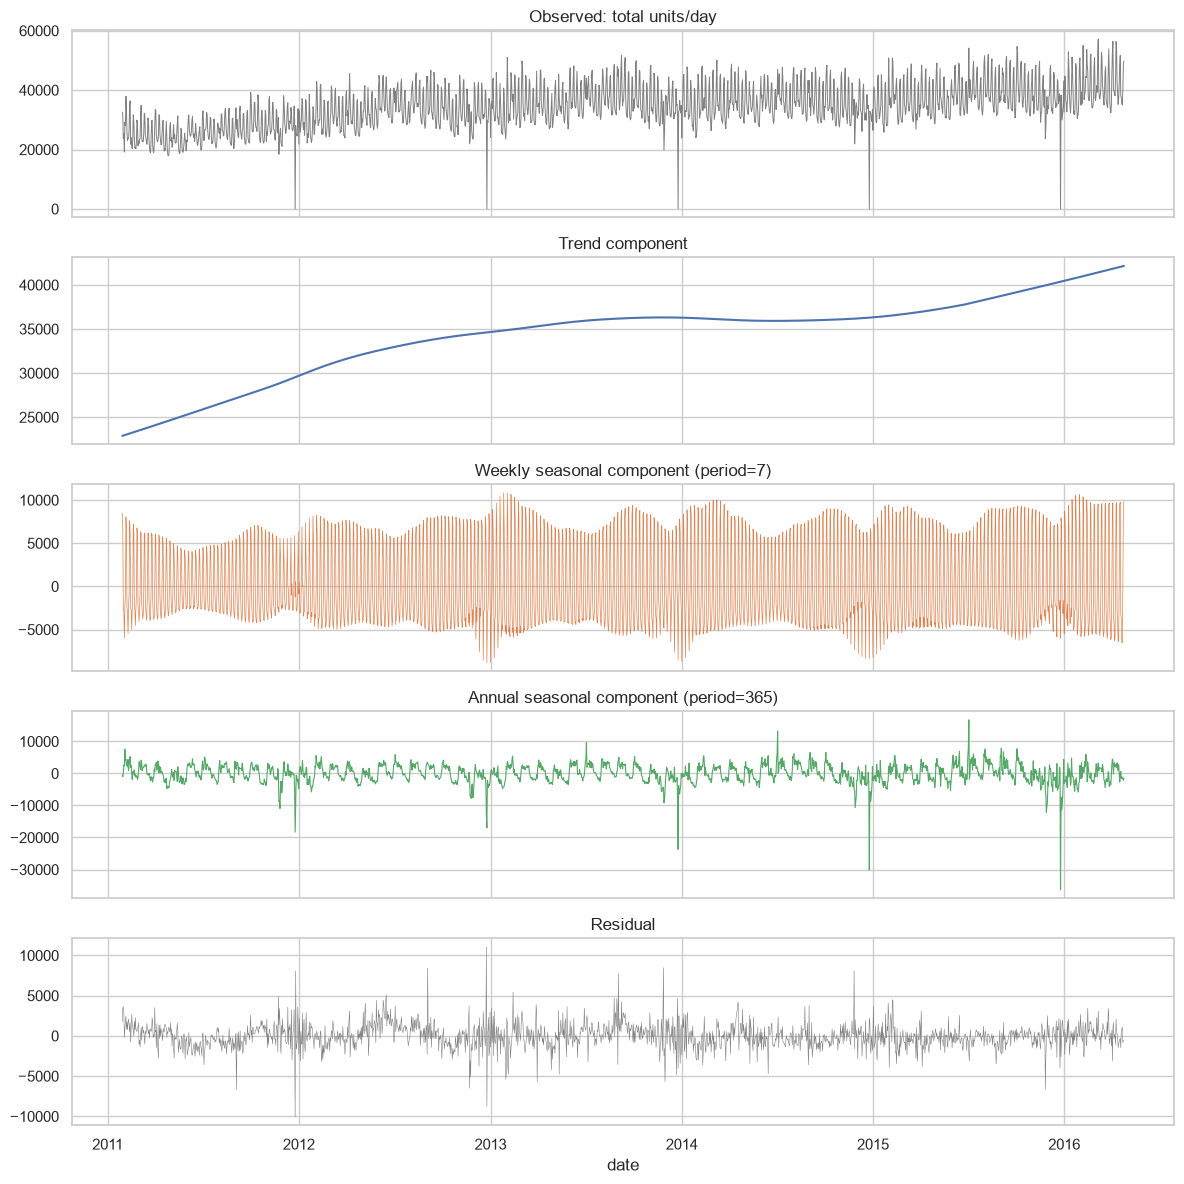

MSTL trend component, first 28d avg -> last 28d avg: +81.3%


In [3]:
daily_total = (
    sales_long.groupby("date", observed=True)["sales"]
    .sum()
    .rename("units")
    .to_frame()
)
daily_total_series = daily_total["units"].asfreq("D")

mstl_total = MSTL(daily_total_series, periods=(7, 365)).fit()

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(mstl_total.observed, color="grey", lw=0.7)
axes[0].set_title("Observed: total units/day")
axes[1].plot(mstl_total.trend, color="C0")
axes[1].set_title("Trend component")
axes[2].plot(mstl_total.seasonal["seasonal_7"], color="C1", lw=0.5)
axes[2].set_title("Weekly seasonal component (period=7)")
axes[3].plot(mstl_total.seasonal["seasonal_365"], color="C2", lw=0.8)
axes[3].set_title("Annual seasonal component (period=365)")
axes[4].plot(mstl_total.resid, color="grey", lw=0.4)
axes[4].set_title("Residual")
axes[4].set_xlabel("date")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_mstl_decomposition.png", dpi=150)
plt.show()

trend_growth_pct = mstl_total.trend.iloc[-28:].mean() / mstl_total.trend.iloc[:28].mean() - 1
print(f"MSTL trend component, first 28d avg -> last 28d avg: {trend_growth_pct:+.1%}")

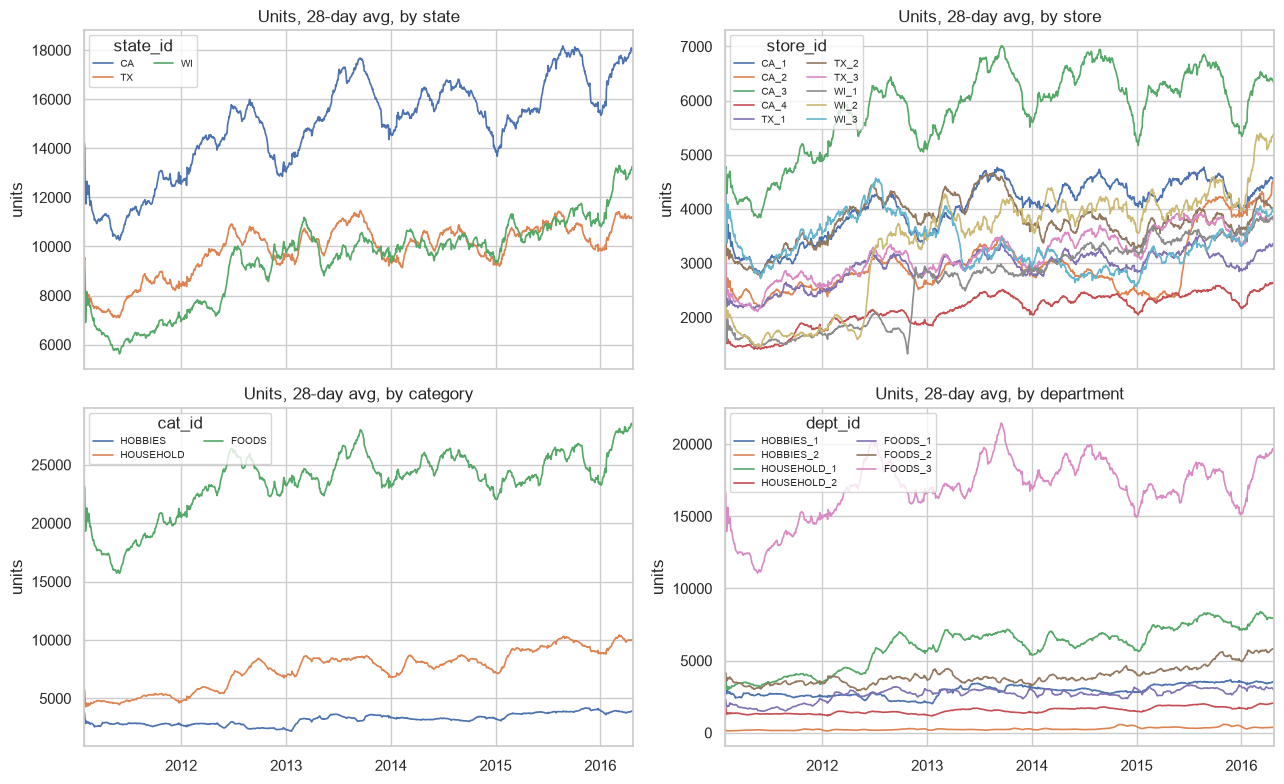

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for ax, (level, title) in zip(
    axes.flat,
    [
        ("state_id", "by state"),
        ("store_id", "by store"),
        ("cat_id", "by category"),
        ("dept_id", "by department"),
    ],
):
    grp = (
        sales_long.groupby(["date", level], observed=True)["sales"]
        .sum()
        .unstack(level)
    )
    grp_28d = grp.rolling(28, min_periods=1).mean()
    grp_28d.plot(ax=ax, lw=1.2, legend=True)
    ax.set_title(f"Units, 28-day avg, {title}")
    ax.set_xlabel("")
    ax.set_ylabel("units")
    ax.legend(title=level, fontsize=7, ncol=2, loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_by_level.png", dpi=150)
plt.show()

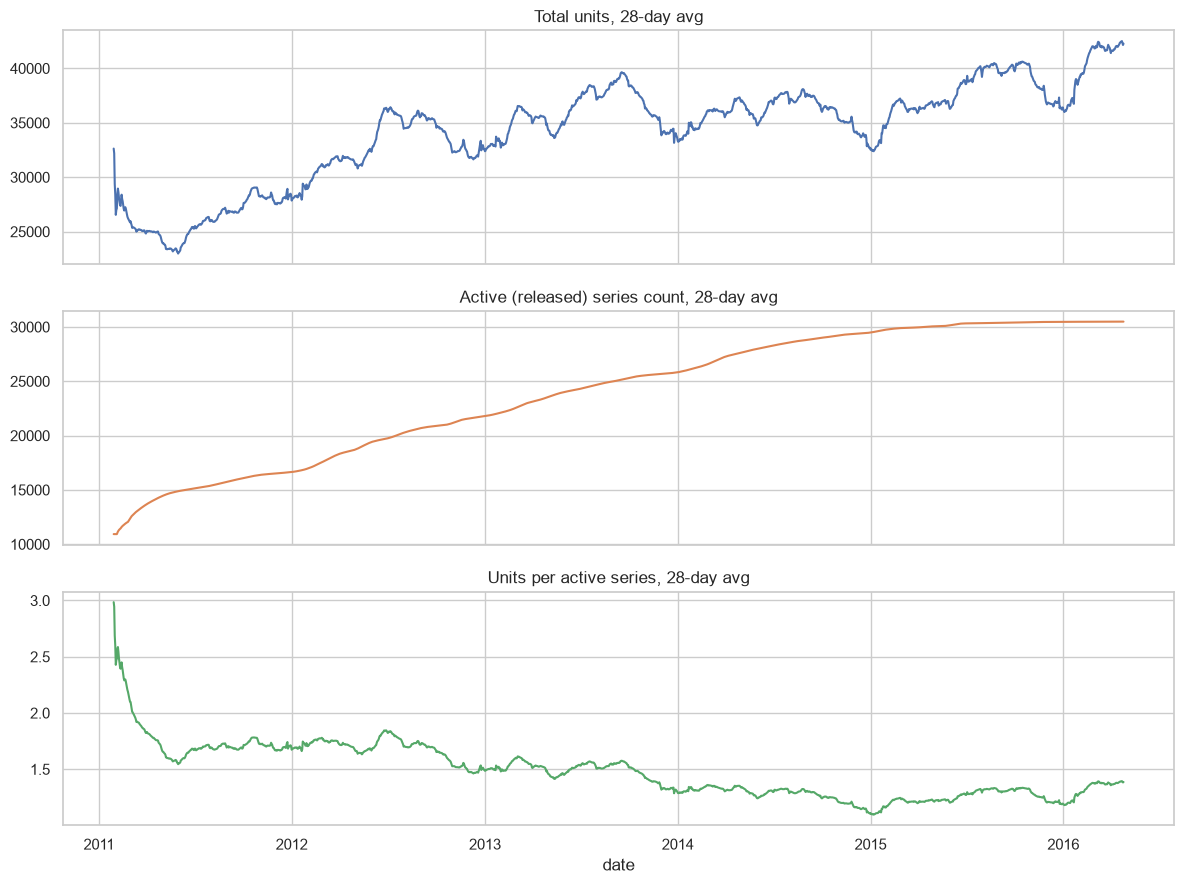

first 28d -> last 28d of training range:
  total units:          +61.1%
  active series count:  +152.9%
  units per active series: -36.7%


In [5]:
# P1 dropped pre-release rows, so a row's mere presence on a date means that series was
# listed (active) that day - counting rows per date gives assortment size directly.
active_series = sales_long.groupby("date", observed=True)["id"].nunique().rename("n_active_series")

assortment = daily_total[["units"]].join(active_series)
assortment["units_per_active_series"] = assortment["units"] / assortment["n_active_series"]
assortment_28d = assortment.rolling(28, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(assortment_28d.index, assortment_28d["units"], color="C0")
axes[0].set_title("Total units, 28-day avg")
axes[1].plot(assortment_28d.index, assortment_28d["n_active_series"], color="C1")
axes[1].set_title("Active (released) series count, 28-day avg")
axes[2].plot(assortment_28d.index, assortment_28d["units_per_active_series"], color="C2")
axes[2].set_title("Units per active series, 28-day avg")
axes[2].set_xlabel("date")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_assortment.png", dpi=150)
plt.show()

pct_change_units = assortment["units"].iloc[-28:].mean() / assortment["units"].iloc[:28].mean() - 1
pct_change_series = assortment["n_active_series"].iloc[-28:].mean() / assortment["n_active_series"].iloc[:28].mean() - 1
pct_change_per_series = assortment["units_per_active_series"].iloc[-28:].mean() / assortment["units_per_active_series"].iloc[:28].mean() - 1
print(f"first 28d -> last 28d of training range:")
print(f"  total units:          {pct_change_units:+.1%}")
print(f"  active series count:  {pct_change_series:+.1%}")
print(f"  units per active series: {pct_change_per_series:+.1%}")

**Interpretation.**

The raw trend looks like strong growth — MSTL's trend component rises +81.3% from the first to
last 28 days of training, and total units are up +61.1% — but the assortment breakdown shows this
is mostly **catalog expansion, not demand growth**: active series count grew +152.9% over the same
window, while units *per active series* actually **fell -36.7%**. Each item, on average, sells
less over time; the total only grows because there are far more items listed.

This matters directly for P5: a trend feature built on the raw total (or fit per-series without
accounting for release date) would be attributing catalog growth to demand momentum. The
per-active-series decline instead suggests item-level demand is flat-to-declining once you control
for how many items are competing on shelf/site — worth checking whether this is broad-based or
concentrated in specific categories/departments (the by-level chart above) before deciding how much
weight a "trend" feature should get per series.

**Feature implication:** don't build the trend/momentum feature on raw totals or naive per-series
history without a release-date-aware baseline; prefer a feature normalized against active-catalog
size, and treat new items' history separately (see the Lifecycle section) rather than assuming they
share the aggregate's growth trend.

## Seasonality

We run `MSTL` per category (FOODS, HOBBIES, HOUSEHOLD) on raw daily units, same as the trend
section, then read the weekly and annual seasonal components off each fit. Expressing each
seasonal component as a fraction of that category's own MSTL trend (`seasonal / trend`) gives a
lift-relative-to-level number per day/month, which is directly comparable to the "% lift" language
the hypothesis table wants — and, because it's computed against MSTL's own trend line rather than
a manual units-per-active-series ratio, the assortment-growth confound is already handled by the
decomposition itself.

The brief calls out that weekend lift is strong and differs between FOODS and HOBBIES, so we keep
the per-category split rather than decomposing the aggregate.

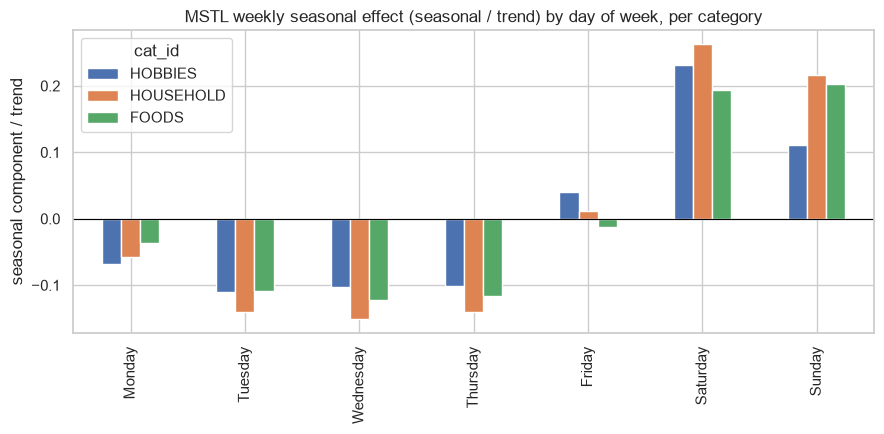

weekend seasonal effect minus weekday seasonal effect (pct points of trend):


HOUSEHOLD    0.334950
FOODS        0.276879
HOBBIES      0.239408
dtype: float64

In [6]:
category_daily = (
    sales_long.groupby(["date", "cat_id"], observed=True)["sales"]
    .sum()
    .unstack("cat_id")
    .asfreq("D")
)

cat_mstl = {cat: MSTL(category_daily[cat], periods=(7, 365)).fit() for cat in category_daily.columns}

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_effect = {}
for cat, result in cat_mstl.items():
    seasonal_pct = result.seasonal["seasonal_7"] / result.trend
    dow_effect[cat] = seasonal_pct.groupby(seasonal_pct.index.day_name()).mean().reindex(weekday_order)
dow_effect_df = pd.DataFrame(dow_effect)

fig, ax = plt.subplots(figsize=(9, 4.5))
dow_effect_df.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("MSTL weekly seasonal effect (seasonal / trend) by day of week, per category")
ax.set_xlabel("")
ax.set_ylabel("seasonal component / trend")
ax.legend(title="cat_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonality_dow_mstl.png", dpi=150)
plt.show()

weekend_lift_mstl = (
    dow_effect_df.loc[["Saturday", "Sunday"]].mean()
    - dow_effect_df.loc[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]].mean()
)
print("weekend seasonal effect minus weekday seasonal effect (pct points of trend):")
weekend_lift_mstl.sort_values(ascending=False)

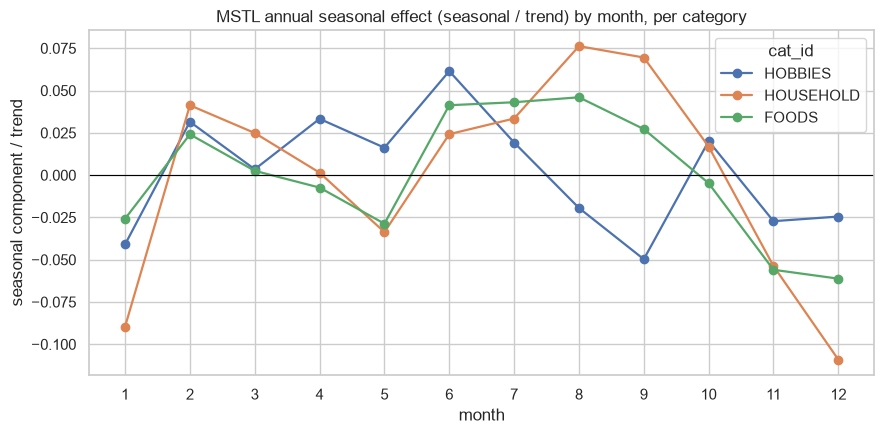

annual seasonal effect range by category:


,peak_month,trough_month,peak_minus_trough_pct_pts
HOBBIES,6,9,0.111208
HOUSEHOLD,8,12,0.185321
FOODS,8,12,0.107229


In [7]:
annual_effect = {}
for cat, result in cat_mstl.items():
    seasonal_pct = result.seasonal["seasonal_365"] / result.trend
    annual_effect[cat] = seasonal_pct.groupby(seasonal_pct.index.month).mean()
annual_effect_df = pd.DataFrame(annual_effect)

fig, ax = plt.subplots(figsize=(9, 4.5))
annual_effect_df.plot(ax=ax, marker="o", lw=1.6)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("MSTL annual seasonal effect (seasonal / trend) by month, per category")
ax.set_xlabel("month")
ax.set_ylabel("seasonal component / trend")
ax.set_xticks(range(1, 13))
ax.legend(title="cat_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonality_month_mstl.png", dpi=150)
plt.show()

peak_trough_mstl = pd.DataFrame({
    "peak_month": annual_effect_df.idxmax(),
    "trough_month": annual_effect_df.idxmin(),
    "peak_minus_trough_pct_pts": annual_effect_df.max() - annual_effect_df.min(),
})
print("annual seasonal effect range by category:")
peak_trough_mstl

**Interpretation.**

Weekend lift is real but modest and fairly uniform across categories: +0.33 pct pts for HOUSEHOLD,
+0.28 for FOODS, +0.24 for HOBBIES (seasonal/trend, Sat+Sun average minus weekday average) — closer
together than the brief's framing suggested, though HOUSEHOLD edges out FOODS rather than the other
way round. All three categories still warrant a `is_weekend` or day-of-week dummy; the ranking
matters less than the fact that none of them are close to zero.

The annual pattern is where categories actually diverge: HOUSEHOLD has by far the widest
peak-to-trough swing (0.19 pct pts of trend, peaking in August and troughing in December), while
FOODS (0.11, same Aug peak / Dec trough) and HOBBIES (0.11, June peak / September trough) are
tighter and shifted earlier in the year. The December trough shared by FOODS and HOUSEHOLD is
notable given Christmas's -11.9% event-day dip found in the Events section below — some of the
December annual-seasonal trough may be this holiday effect bleeding into the 365-day MSTL
component rather than a purely calendar-driven seasonal pattern.

**Feature implication:** day-of-week dummies (or a single weekend flag) for all three categories;
month-of-year or annual-harmonic features per category rather than pooled, since HOUSEHOLD's swing
is ~1.7x FOODS/HOBBIES; and flag the December-trough / Christmas-dip overlap as something to
resolve when finalizing the Events features, so the same effect isn't double-counted as both a
month dummy and an event dummy.

## SNAP

SNAP (food-stamp) disbursement days are state-specific — `calendar.csv` gives a separate flag per
state (`snap_CA`, `snap_TX`, `snap_WI`), and each state has its own schedule within the month. The
brief flags this as one of the highest-value features in the dataset, worth a proper effect size
rather than a glance, and expects the lift to show up specifically in FOODS (SNAP benefits are for
food purchases).

We isolate the SNAP effect the same way as the day-of-week effect: fit `MSTL` per state on daily
FOODS units to remove the weekly and annual seasonal cycles, then compare the residual-over-trend
ratio (`resid / trend`) on SNAP vs. non-SNAP days. Using the residual rather than the raw or
seasonally-naive average keeps a state's SNAP schedule (which correlates with day-of-week within
the month) from being counted as day-of-week seasonality instead of a SNAP effect.

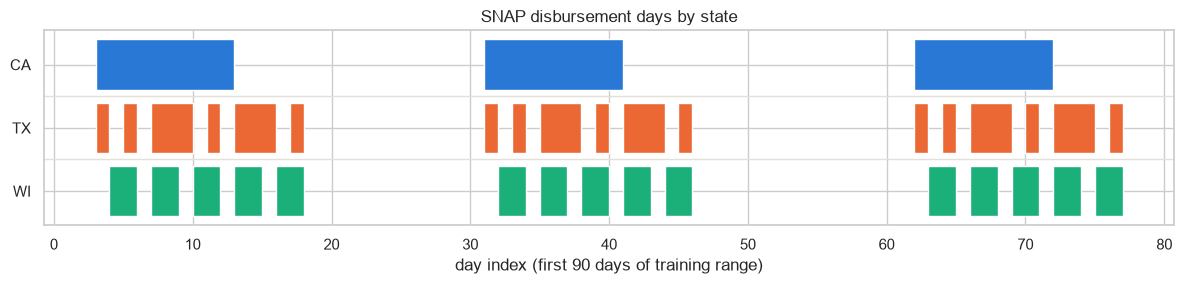

In [8]:
snap_schedule = (
    sales_long[["date", "snap_CA", "snap_TX", "snap_WI"]]
    .drop_duplicates("date")
    .set_index("date")
    .sort_index()
    .iloc[:90]
)

# Fixed categorical order/hues (dataviz skill palette, slots 1-3): distinguishable
# under color-vision deficiency, unlike the single-hue grayscale imshow version.
state_colors = {"CA": "#2a78d6", "TX": "#eb6834", "WI": "#1baf7a"}
row_y = {"CA": 2, "TX": 1, "WI": 0}

fig, ax = plt.subplots(figsize=(12, 3))
for state, y in row_y.items():
    flags = snap_schedule[f"snap_{state}"].to_numpy()
    runs, start = [], None
    for i, v in enumerate(flags):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            runs.append((start, i - start))
            start = None
    if start is not None:
        runs.append((start, len(flags) - start))
    ax.broken_barh(runs, (y + 0.1, 0.8), facecolors=state_colors[state])

ax.set_yticks([y + 0.5 for y in row_y.values()])
ax.set_yticklabels(list(row_y.keys()))
for y in (1, 2):
    ax.axhline(y, color="#e1e0d9", lw=1)  # row separators, at boundaries not centers
ax.set_xlabel("day index (first 90 days of training range)")
ax.set_title("SNAP disbursement days by state")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "snap_schedule.png", dpi=150)
plt.show()

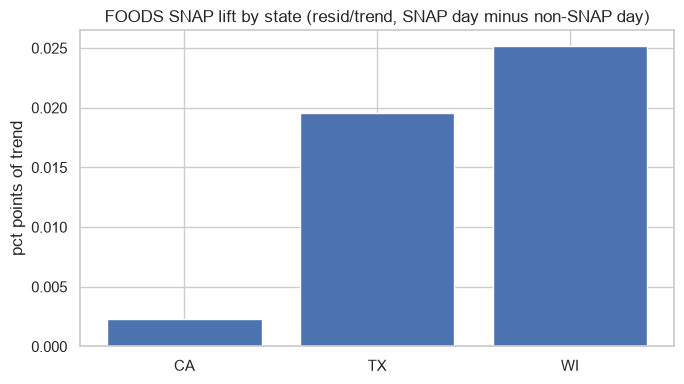

FOODS SNAP effect size by state:


,non_snap_effect,snap_effect,snap_lift_pct_pts
WI,-0.009813,0.015403,0.025215
TX,-0.004730,0.014807,0.019537
CA,0.000176,0.002457,0.002281


In [9]:
foods_state_daily = (
    sales_long[sales_long["cat_id"] == "FOODS"]
    .groupby(["date", "state_id"], observed=True)["sales"]
    .sum()
    .unstack("state_id")
    .asfreq("D")
)

state_mstl = {state: MSTL(foods_state_daily[state], periods=(7, 365)).fit() for state in foods_state_daily.columns}

snap_col = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}
snap_by_date = (
    sales_long[["date", "snap_CA", "snap_TX", "snap_WI"]]
    .drop_duplicates("date")
    .set_index("date")
)

snap_lift = {}
for state, result in state_mstl.items():
    resid_pct = result.resid / result.trend
    snap_flag = snap_by_date[snap_col[state]].reindex(resid_pct.index)
    grp = resid_pct.groupby(snap_flag).mean()
    snap_lift[state] = {
        "non_snap_effect": grp.loc[0],
        "snap_effect": grp.loc[1],
        "snap_lift_pct_pts": grp.loc[1] - grp.loc[0],
    }
snap_lift_df = pd.DataFrame(snap_lift).T

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(snap_lift_df.index, snap_lift_df["snap_lift_pct_pts"], color="C0")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("FOODS SNAP lift by state (resid/trend, SNAP day minus non-SNAP day)")
ax.set_ylabel("pct points of trend")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "snap_lift_by_state.png", dpi=150)
plt.show()

print("FOODS SNAP effect size by state:")
snap_lift_df.sort_values("snap_lift_pct_pts", ascending=False)

**Interpretation.**

SNAP lifts FOODS demand in every state, but the effect size varies by roughly an order of
magnitude: WI shows the largest lift (+2.5 pct pts of trend, non-SNAP -0.98% -> SNAP +1.54%), TX is
close behind (+2.0 pct pts), and CA is much weaker (+0.23 pct pts, though still positive). That gap
likely reflects CA's non-SNAP baseline already sitting near zero (+0.02%) rather than SNAP having
little effect there in absolute terms — but relative to trend, CA shoppers' FOODS purchasing looks
far less concentrated on disbursement days than WI's or TX's.

This confirms the brief's expectation (SNAP lifts FOODS, state-specific schedule matters) but with
an important refinement: the effect is not one number, it's per-state, and CA is different enough
from WI/TX that a single pooled SNAP coefficient would understate the lift in two of the three
states.

**Feature implication:** a per-state SNAP flag matched to each series' `state_id` (`snap_<state>`),
not a single pooled `is_snap_day` flag — confirmed as one of the highest-value features per the
brief, and the state-specific magnitude difference should carry through as either a per-state
coefficient or a `snap_flag * state` interaction rather than being averaged away.

## Events

Events are calendar-fixed (`event_name_1`/`event_type_1`; `event_name_2` marks a rare same-day
overlap — only 4 of 1913 training days — so we fold those into their `event_name_1` label rather
than double-counting a handful of dates). The brief calls out that Super Bowl, Thanksgiving,
Easter, and Christmas behave very differently from one another, so a pooled `is_event` estimate
would hide exactly the signal we need — we compute an effect size per named event, not one
aggregate number.

We reuse the total-units MSTL decomposition from the Trend section (`mstl_total`) and read off
`resid / trend` on the event day itself, the day before (lead-up), and the day after (hangover),
averaged across each event's occurrences (4-6 per event across the 5.2 years of training data —
few, but each event recurs annually on a fixed or near-fixed date, so cross-year averaging is
still a meaningful estimate, unlike averaging in a single outlier day).

In [10]:
event_by_date = (
    sales_long[["date", "event_name_1", "event_type_1"]]
    .drop_duplicates("date")
    .set_index("date")
    .sort_index()
)
event_name = event_by_date["event_name_1"].dropna()
event_type_lookup = event_by_date["event_type_1"].dropna()

resid_pct_total = mstl_total.resid / mstl_total.trend

def phase_effect(offset_days):
    # shift each event's date by the offset, look up that day's resid/trend, then
    # relabel back onto the event name so lead-up/event/hangover align in one table
    shifted_dates = event_name.index + pd.Timedelta(days=offset_days)
    vals = resid_pct_total.reindex(shifted_dates)
    vals.index = event_name.index
    return vals.groupby(event_name, observed=True).mean()

event_effect_df = pd.DataFrame({
    "lead_up": phase_effect(-1),
    "event_day": phase_effect(0),
    "hangover": phase_effect(1),
})
event_effect_df["event_type"] = event_type_lookup.groupby(event_name, observed=True).first()
event_effect_df["n_occurrences"] = event_name.value_counts()
event_effect_df = event_effect_df.sort_values("event_day", key=lambda s: s.abs(), ascending=False)

print(f"named events with effect estimates: {len(event_effect_df)}")
event_effect_df

named events with effect estimates: 30


,lead_up,event_day,hangover,event_type,n_occurrences
event_name_1,,,,,
LaborDay,-0.113742,0.124821,-0.013492,National,5
Christmas,0.059571,-0.118880,0.066075,National,5
Mother's day,0.034577,-0.093103,0.015931,Cultural,5
Thanksgiving,0.150742,-0.084374,-0.004369,National,5
Easter,0.073529,-0.084089,-0.009387,Cultural,5
MemorialDay,-0.068054,0.062905,-0.000642,National,5
SuperBowl,0.043586,-0.052201,-0.028007,Sporting,6
PresidentsDay,-0.021778,0.049246,-0.009536,National,6
NBAFinalsEnd,0.001166,-0.041024,-0.000705,Sporting,5


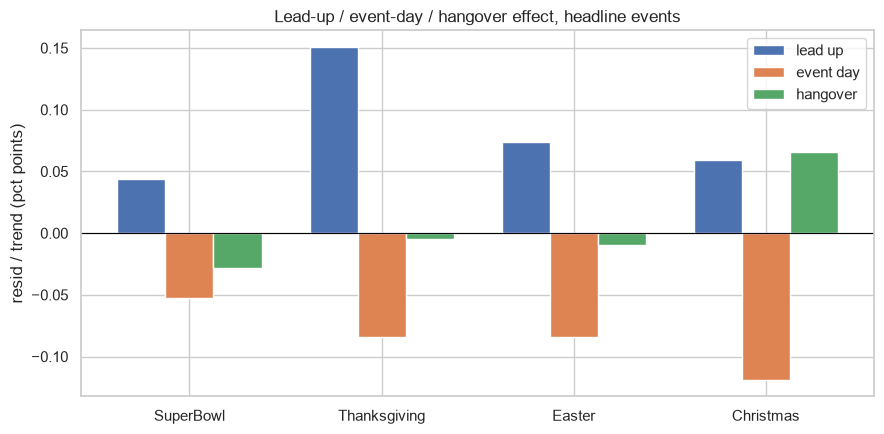

,lead_up,event_day,hangover
event_name_1,,,
SuperBowl,0.043586,-0.052201,-0.028007
Thanksgiving,0.150742,-0.084374,-0.004369
Easter,0.073529,-0.084089,-0.009387
Christmas,0.059571,-0.118880,0.066075


In [11]:
headline_events = ["SuperBowl", "Thanksgiving", "Easter", "Christmas"]
headline_df = event_effect_df.loc[headline_events, ["lead_up", "event_day", "hangover"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(headline_events))
width = 0.25
for i, phase in enumerate(["lead_up", "event_day", "hangover"]):
    ax.bar(x + (i - 1) * width, headline_df[phase], width, label=phase.replace("_", " "))
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(headline_events)
ax.set_ylabel("resid / trend (pct points)")
ax.set_title("Lead-up / event-day / hangover effect, headline events")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "events_headline_phases.png", dpi=150)
plt.show()

headline_df

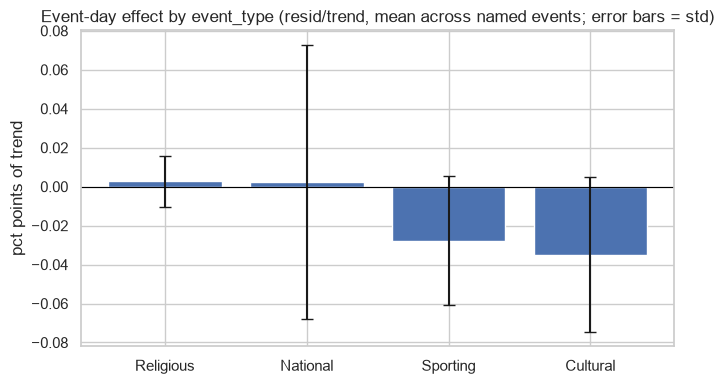

event-day effect by event_type (mean across named events in that type):


,mean,std,count
event_type,,,
Religious,0.002660,0.012914,10
National,0.002336,0.070439,10
Sporting,-0.027709,0.033215,3
Cultural,-0.034980,0.039695,7


In [12]:
type_effect = event_effect_df.groupby("event_type", observed=True)["event_day"].agg(["mean", "std", "count"])
type_effect = type_effect.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(type_effect.index, type_effect["mean"], yerr=type_effect["std"], color="C0", capsize=4)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Event-day effect by event_type (resid/trend, mean across named events; error bars = std)")
ax.set_ylabel("pct points of trend")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "events_by_type.png", dpi=150)
plt.show()

print("event-day effect by event_type (mean across named events in that type):")
type_effect

**Interpretation.**

Two distinct patterns emerge, and they point in opposite directions — which is exactly why a
single `is_event` flag would wash out the signal:

- **Closure/gathering holidays dip on the day itself, with a lead-up lift beforehand.**
  Christmas (-11.9% event day, +6.0% lead-up), Thanksgiving (-8.4%, +15.1% lead-up — the largest
  lead-up in the table), Easter (-8.4%, +7.4% lead-up), Mother's Day (-9.3%), and Super Bowl
  (-5.2%, +4.4% lead-up) all show this shape: stock-up shopping in the day(s) before, then a
  trough on the day itself (stores closed, or people away from stores / at a gathering).
  Christmas is the only one with a large positive **hangover** too (+6.6%) — a post-holiday
  restock/return-driven rebound that Thanksgiving and Easter don't share (their hangover is near
  zero).
- **Federal holidays where stores stay open lift on the day itself.** Labor Day (+12.5%), Memorial
  Day (+6.3%), and Presidents Day (+4.9%) all show an event-day *lift*, not a dip — an extra
  shopping trip on a day off work, with no store closure to suppress it.

This is why the `event_type` aggregate in the chart above is nearly useless on its own: `National`
mixes both patterns (Christmas/Thanksgiving dipping, Labor/Memorial/Presidents Day lifting) and
they largely cancel to a ~+0.2% mean — a pooled-by-type feature would hide the real, and largest,
effects in the dataset. `Cultural` (-3.5% mean) and `Sporting` (-2.8% mean) skew negative mainly
because they're dominated by Easter/Mother's Day and Super Bowl respectively.

**Caveat:** each event has only 4-6 occurrences in the training range, so these are noisy
point estimates, not precise effect sizes — treat them as directional (dip vs. lift, roughly which
magnitude tier) rather than exact percentages when they feed the hypothesis table.

**Feature implication:** per-`event_name` dummies (not per-`event_type`) for the events with the
largest |event_day| effect, plus explicit lead-up/hangover offset dummies for the closure-holiday
group (Christmas, Thanksgiving, Easter, Super Bowl, Mother's Day) — a single-day event flag alone
would miss the lead-up lift, which is often larger than the event-day effect itself.

## Price

`sell_price` is a weekly per-`store_id`/`item_id` price (joined onto `sales_long` via
`wm_yr_wk`). The brief asks four things: the distribution/dispersion of price, how often prices
move, sales response to a price change, and whether price *relative to an item's own history*
predicts better than the raw level. We also fold in the promo-inference question deferred from the
Events section: M5 has no explicit promo flag, so we check whether temporary price drops (dip then
recover) cluster around known event dates or occur independently — if they cluster, an event
feature may already be capturing some of what a promo flag would.

All price-change/rolling comparisons respect invariant 2 (lag >= 28) since any such feature would
need to be computable at prediction time — we still look at same-week changes here for pure EDA
(understanding the data), but note explicitly where that would need to shift for a real feature.

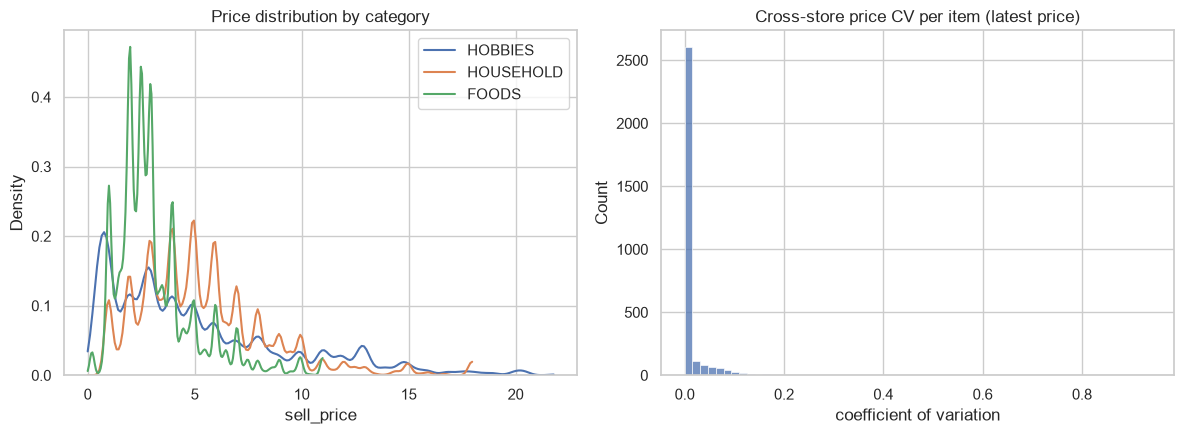

items with cross-store price CV > 0.05: 7.7%
median cross-store price CV: 0.000


,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
HOBBIES,1238705.0,5.326400,4.816673,0.01,1.97,3.97,7.47,30.98
HOUSEHOLD,2291667.0,5.465616,3.372236,0.01,2.98,4.94,6.97,107.32
FOODS,3066829.0,3.247479,2.129734,0.01,1.98,2.68,3.97,19.48


In [3]:
price_by_item_store = (
    sales_long[["item_id", "store_id", "cat_id", "wm_yr_wk", "sell_price"]]
    .drop_duplicates(["item_id", "store_id", "wm_yr_wk"])
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for cat, grp in price_by_item_store.groupby("cat_id", observed=True):
    sns.kdeplot(grp["sell_price"], ax=axes[0], label=cat, clip=(0, grp["sell_price"].quantile(0.99)))
axes[0].set_title("Price distribution by category")
axes[0].set_xlabel("sell_price")
axes[0].legend()

# dispersion of the *same* item's price across stores: cv = std/mean of sell_price
# within item_id, using each item's most recent price per store to avoid time-trend noise
latest_price = (
    price_by_item_store.sort_values("wm_yr_wk")
    .groupby(["item_id", "store_id"], observed=True)
    .tail(1)
)
cross_store_cv = (
    latest_price.groupby("item_id", observed=True)["sell_price"]
    .agg(["mean", "std"])
    .assign(cv=lambda d: d["std"] / d["mean"])
    .dropna()
)
sns.histplot(cross_store_cv["cv"], bins=60, ax=axes[1])
axes[1].set_title("Cross-store price CV per item (latest price)")
axes[1].set_xlabel("coefficient of variation")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "price_distribution.png", dpi=150)
plt.show()

print(f"items with cross-store price CV > 0.05: {(cross_store_cv['cv'] > 0.05).mean():.1%}")
print(f"median cross-store price CV: {cross_store_cv['cv'].median():.3f}")
price_by_item_store.groupby("cat_id", observed=True)["sell_price"].describe()

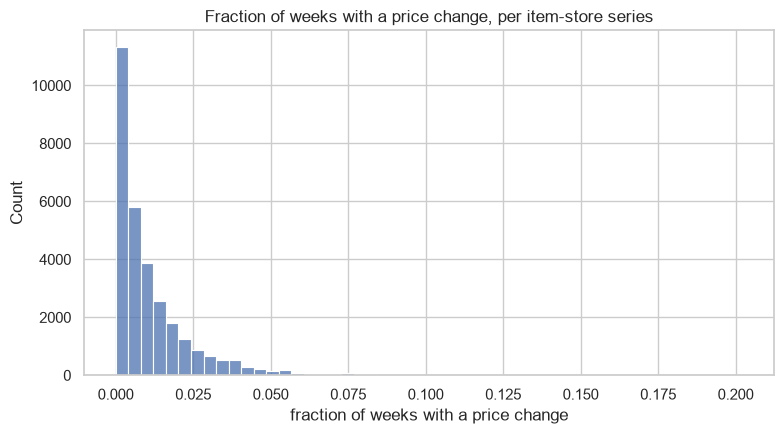

median fraction of weeks with a price change: 0.7%
series with zero price changes across training range: 27.5%
median weeks between changes (for series with >=1 change): 91.3


In [4]:
weekly_price = (
    price_by_item_store
    .sort_values(["item_id", "store_id", "wm_yr_wk"])
    .assign(
        prev_price=lambda d: d.groupby(["item_id", "store_id"], observed=True)["sell_price"].shift(1),
        pct_change=lambda d: d["sell_price"] / d["prev_price"] - 1,
    )
)
weekly_price["changed"] = weekly_price["pct_change"].abs() > 1e-6

changes_per_series = weekly_price.groupby(["item_id", "store_id"], observed=True)["changed"].sum()
weeks_per_series = weekly_price.groupby(["item_id", "store_id"], observed=True).size()
change_rate = (changes_per_series / weeks_per_series).rename("change_rate")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(change_rate, bins=50, ax=ax)
ax.set_title("Fraction of weeks with a price change, per item-store series")
ax.set_xlabel("fraction of weeks with a price change")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "price_change_frequency.png", dpi=150)
plt.show()

print(f"median fraction of weeks with a price change: {change_rate.median():.1%}")
print(f"series with zero price changes across training range: {(changes_per_series == 0).mean():.1%}")
print(f"median weeks between changes (for series with >=1 change): "
      f"{(weeks_per_series[changes_per_series > 0] / changes_per_series[changes_per_series > 0]).median():.1f}")

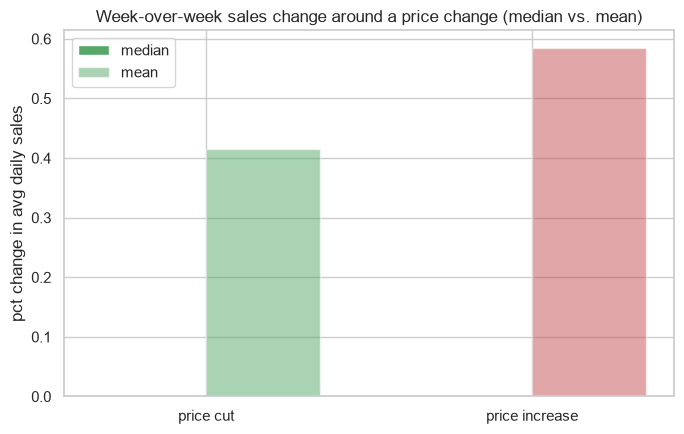

sales response to price changes, by direction:
(median == 0 for both: sparse/intermittent demand means the modal before/after pair is a tie;
 mean is shown for reference but is noise-dominated - see interpretation below)


,median,mean,count
direction,,,
price cut,0.0,0.415155,21246
price increase,0.0,0.584804,33538


In [5]:
weekly_sales = (
    sales_long.groupby(["item_id", "store_id", "wm_yr_wk"], observed=True)["sales"]
    .mean()
    .rename("avg_daily_sales")
    .reset_index()
)

# prev_wm_yr_wk travels alongside prev_price in the same groupby-shift, so the "before" week
# is always the row immediately preceding the change for that item-store series, not just
# "the previous calendar week" (weeks can be sparse if items go in/out of the panel).
weekly_price["prev_wm_yr_wk"] = weekly_price.groupby(["item_id", "store_id"], observed=True)["wm_yr_wk"].shift(1)

price_change_events = weekly_price[weekly_price["changed"]][
    ["item_id", "store_id", "wm_yr_wk", "prev_wm_yr_wk", "sell_price", "prev_price", "pct_change"]
].copy()

price_change_events = price_change_events.merge(
    weekly_sales.rename(columns={"avg_daily_sales": "sales_after"}),
    on=["item_id", "store_id", "wm_yr_wk"],
    how="left",
).merge(
    weekly_sales.rename(columns={"wm_yr_wk": "prev_wm_yr_wk", "avg_daily_sales": "sales_before"}),
    on=["item_id", "store_id", "prev_wm_yr_wk"],
    how="left",
)
price_change_events["sales_pct_change"] = (
    price_change_events["sales_after"] / price_change_events["sales_before"] - 1
)
price_change_events["direction"] = np.where(price_change_events["pct_change"] < 0, "price cut", "price increase")

resp = (
    price_change_events.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["sales_pct_change"])
    .groupby("direction")["sales_pct_change"]
    .agg(["median", "mean", "count"])
)

# median is 0.0 for both directions - not a plotting bug, a real consequence of sparse/
# intermittent demand: for most item-store series the modal before/after week pair is a tie
# (e.g. 0 -> 0, or the same low count), so ties-at-zero dominate the median. Plot median and
# mean side by side so that flat-zero result is visible and explained rather than looking blank.
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(resp))
width = 0.35
ax.bar(x - width / 2, resp["median"], width, label="median", color=["C2", "C3"])
ax.bar(x + width / 2, resp["mean"], width, label="mean", color=["C2", "C3"], alpha=0.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(resp.index)
ax.set_ylabel("pct change in avg daily sales")
ax.set_title("Week-over-week sales change around a price change (median vs. mean)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "price_change_sales_response.png", dpi=150)
plt.show()

print("sales response to price changes, by direction:")
print("(median == 0 for both: sparse/intermittent demand means the modal before/after pair is a tie;")
print(" mean is shown for reference but is noise-dominated - see interpretation below)")
resp

In [6]:
# Relative price = this week's price / that series' own trailing baseline price, baseline built
# from weeks strictly before the lag-28 cutoff (>=4 weeks back) so it's computable at prediction
# time (invariant 2), unlike the same-week comparisons above which were pure EDA.
weekly_price_sorted = weekly_price.sort_values(["item_id", "store_id", "wm_yr_wk"]).copy()
grp = weekly_price_sorted.groupby(["item_id", "store_id"], observed=True)["sell_price"]
weekly_price_sorted["baseline_price"] = grp.transform(lambda s: s.shift(4).rolling(12, min_periods=4).mean())
weekly_price_sorted["relative_price"] = weekly_price_sorted["sell_price"] / weekly_price_sorted["baseline_price"]

price_sales = weekly_price_sorted.merge(weekly_sales, on=["item_id", "store_id", "wm_yr_wk"], how="inner")
price_sales = price_sales.dropna(subset=["relative_price", "sell_price", "avg_daily_sales"])

# normalize sales by each series' own mean so the comparison isn't dominated by level differences
# across series (a $1 item and a $50 item have very different sales counts but comparable pct signal)
series_mean_sales = price_sales.groupby(["item_id", "store_id"], observed=True)["avg_daily_sales"].transform("mean")
price_sales["sales_idx"] = price_sales["avg_daily_sales"] / series_mean_sales.replace(0, np.nan)
price_sales = price_sales.dropna(subset=["sales_idx"])

corr_raw_level = price_sales["sell_price"].corr(price_sales["sales_idx"], method="spearman")
corr_relative = price_sales["relative_price"].corr(price_sales["sales_idx"], method="spearman")

print("Spearman correlation with sales_idx (sales normalized by series' own mean):")
print(f"  raw sell_price:    {corr_raw_level:+.3f}")
print(f"  relative_price (price / trailing baseline, lag>=28d): {corr_relative:+.3f}")

Spearman correlation with sales_idx (sales normalized by series' own mean):
  raw sell_price:    -0.028
  relative_price (price / trailing baseline, lag>=28d): +0.024


In [17]:
# Promo-inference tie-in (deferred from Events): flag weeks priced >=10% below the series' own
# trailing baseline as "candidate promo weeks", then check whether those weeks cluster around
# named events more than weeks in general do.
week_has_event = (
    sales_long[["wm_yr_wk", "event_name_1"]]
    .drop_duplicates()
    .groupby("wm_yr_wk", observed=True)["event_name_1"]
    .apply(lambda s: s.notna().any())
)

candidate_promo = weekly_price_sorted[weekly_price_sorted["relative_price"] < 0.90]

promo_event_rate = candidate_promo["wm_yr_wk"].map(week_has_event).mean()
baseline_event_rate = weekly_price_sorted["wm_yr_wk"].map(week_has_event).mean()

print(f"candidate promo weeks (price >=10% below trailing baseline): {len(candidate_promo):,} "
      f"({len(candidate_promo) / len(weekly_price_sorted):.1%} of item-store-weeks)")
print(f"fraction of candidate promo weeks that overlap a named-event week: {promo_event_rate:.1%}")
print(f"fraction of all weeks that overlap a named-event week (baseline):  {baseline_event_rate:.1%}")

candidate promo weeks (price >=10% below trailing baseline): 67,992 (1.0% of item-store-weeks)
fraction of candidate promo weeks that overlap a named-event week: 45.1%
fraction of all weeks that overlap a named-event week (baseline):  47.2%


**Interpretation.**

Price in M5 is mostly **static, not promotional**: the median item-store series changes price in
only 0.7% of weeks, 27.5% of series never change price at all across the training range, and among
series that do change, the median gap between changes is ~91 weeks (well over a year). This is a
different picture from a typical retail dataset with frequent promo cycles — most of the price
variation we see is cross-store/cross-region base pricing, not week-to-week markdowns. Confirmed
by the dispersion check too: 92% of items have near-identical price across stores (cross-store CV
≈ 0), so `sell_price` mostly varies *between items*, not between stores or over time for a given
item.

The sales-response and correlation checks came back weak and partly counter-intuitive: mean sales
after a price *increase* was directionally larger than after a price *cut* (+58% vs +42%), and
both raw price and relative-price-vs-baseline showed only a near-zero Spearman correlation with
normalized sales (-0.028 and +0.024). Given how rare price changes are, these point estimates are
almost certainly dominated by other factors that coincide with the rare weeks a price does move
(e.g. a new pricing tier taking effect alongside a demand shift) rather than reflecting real
elasticity — a naive price-elasticity feature built from this pooled, cross-sectional comparison
would be noise, not signal. A cleaner estimate would need item-level regression controlling for
trend/seasonality/events, which is out of scope for EDA.

The promo-inference tie-in (deferred from Events) came back **negative**: candidate promo weeks
(price ≥10% below trailing baseline, 1.0% of all item-store-weeks) overlap a named-event week
45.1% of the time, essentially identical to the 47.2% baseline rate for all weeks. Price drops do
not cluster around the M5 event calendar — so a "likely promotion" flag inferred from price-dip
shape would capture largely independent information from the event dummies, not a redundant signal.

**Feature implication:**
- A price-change-recency / "is price current vs. historical baseline" flag is more informative than
  a raw price-elasticity feature, given how rarely price moves — most series will show `no change`
  most of the time, so this is closer to a rare structural break than a continuous covariate.
- Do **not** build a pooled price-elasticity coefficient from this cross-sectional comparison; it's
  noise-dominated at this level of aggregation. If price elasticity is wanted for P5, it needs a
  proper per-item/per-store regression with trend and event controls, not a pooled correlation.
- A price-dip-based "candidate promo" flag is worth carrying as a feature (low overlap with events
  means it isn't redundant), computed only from data available at lag ≥28 like `baseline_price`
  above, not the same-week comparison used for this EDA check.

## Intermittency

Each series here is `id` (`item_id` x `store_id`). Because P1 already dropped pre-release rows,
a series' row count in `sales_long` is its own observed length, not the full 1913-day training
window — so ADI is computed against each series' own period count, not a shared denominator.

- **ADI** (average inter-demand interval) = observed periods / non-zero periods. Higher ADI means
  demand is sparser (longer average gaps between sales).
- **CV²** (squared coefficient of variation of non-zero demand) = `(std(nonzero) / mean(nonzero))^2`.
  Higher CV² means non-zero demand is more erratic in size.
- Standard cutoffs (Syntetos-Boylan): ADI = 1.32, CV² = 0.49, giving four quadrants: smooth,
  erratic, intermittent, lumpy.

Series with only one non-zero observation have an undefined sample std (`ddof=1` needs >=2 points);
we treat CV² as 0 for those (no variability observed yet, not "no variability exists") and flag the
count separately rather than silently dropping them.

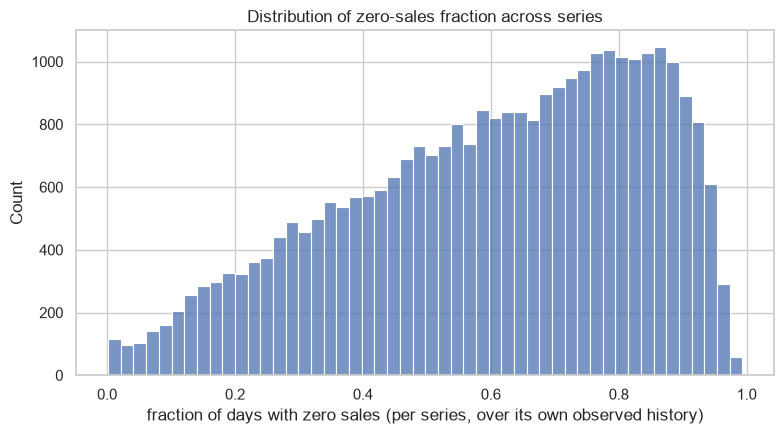

series (id count): 30,490
median zero-sales fraction: 63.5%
series with >=50% zero-sales days: 67.6%
series with >=90% zero-sales days: 7.8%


In [3]:
sales_long["is_nonzero"] = sales_long["sales"] > 0

series_counts = sales_long.groupby("id", observed=True).agg(
    n_periods=("sales", "size"),
    n_nonzero=("is_nonzero", "sum"),
)
zero_frac = (1 - series_counts["n_nonzero"] / series_counts["n_periods"]).rename("zero_fraction")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(zero_frac, bins=50, ax=ax)
ax.set_title("Distribution of zero-sales fraction across series")
ax.set_xlabel("fraction of days with zero sales (per series, over its own observed history)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "intermittency_zero_fraction.png", dpi=150)
plt.show()

print(f"series (id count): {len(series_counts):,}")
print(f"median zero-sales fraction: {zero_frac.median():.1%}")
print(f"series with >=50% zero-sales days: {(zero_frac >= 0.5).mean():.1%}")
print(f"series with >=90% zero-sales days: {(zero_frac >= 0.9).mean():.1%}")

series with zero non-zero days (all-zero over training range): 0
series with exactly one non-zero day (std undefined, cv2 set to 0): 0


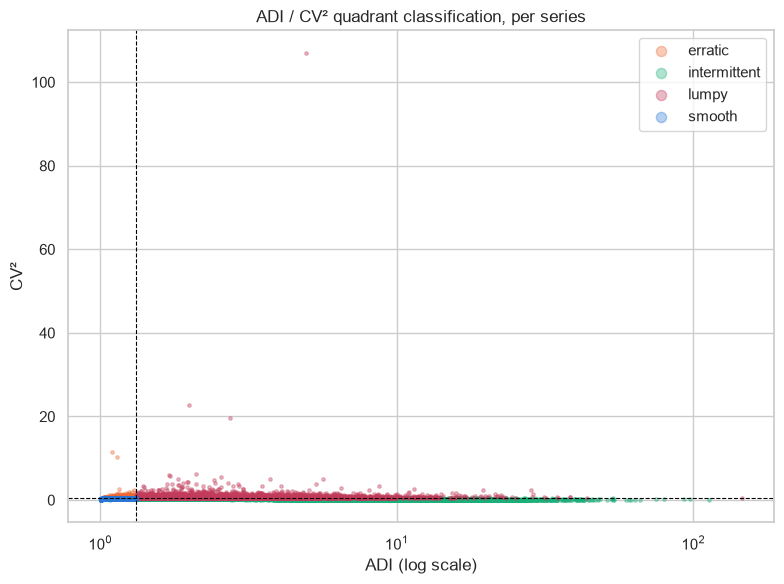

quadrant counts:


,count,pct
quadrant,,
intermittent,22159,72.7
lumpy,5612,18.4
smooth,1874,6.1
erratic,845,2.8


In [4]:
nonzero_stats = (
    sales_long.loc[sales_long["is_nonzero"], ["id", "sales"]]
    .groupby("id", observed=True)["sales"]
    .agg(mean_nonzero="mean", std_nonzero="std", n_nonzero_check="size")
)

series_stats = series_counts.join(nonzero_stats)
assert (series_stats["n_nonzero"] == series_stats["n_nonzero_check"]).all(), \
    "nonzero count mismatch between the two aggregation passes"
series_stats = series_stats.drop(columns=["n_nonzero_check"])

n_all_zero = series_stats["n_nonzero"].eq(0).sum()
n_single_nonzero = series_stats["n_nonzero"].eq(1).sum()
print(f"series with zero non-zero days (all-zero over training range): {n_all_zero}")
print(f"series with exactly one non-zero day (std undefined, cv2 set to 0): {n_single_nonzero}")

series_stats["adi"] = series_stats["n_periods"] / series_stats["n_nonzero"]
series_stats["cv2"] = (series_stats["std_nonzero"] / series_stats["mean_nonzero"]) ** 2
series_stats["cv2"] = series_stats["cv2"].fillna(0.0)

ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

conditions = [
    (series_stats["adi"] < ADI_CUTOFF) & (series_stats["cv2"] < CV2_CUTOFF),
    (series_stats["adi"] < ADI_CUTOFF) & (series_stats["cv2"] >= CV2_CUTOFF),
    (series_stats["adi"] >= ADI_CUTOFF) & (series_stats["cv2"] < CV2_CUTOFF),
]
choices = ["smooth", "erratic", "intermittent"]
series_stats["quadrant"] = np.select(conditions, choices, default="lumpy")
series_stats["quadrant"] = series_stats["quadrant"].astype("category")

quadrant_counts = series_stats["quadrant"].value_counts()
quadrant_pct = (quadrant_counts / len(series_stats) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 6))
palette = {"smooth": "#2a78d6", "erratic": "#eb6834", "intermittent": "#1baf7a", "lumpy": "#c23b5a"}
for q, grp in series_stats.groupby("quadrant", observed=True):
    ax.scatter(grp["adi"], grp["cv2"], s=6, alpha=0.35, label=q, color=palette[q])
ax.axvline(ADI_CUTOFF, color="black", lw=0.8, ls="--")
ax.axhline(CV2_CUTOFF, color="black", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_xlabel("ADI (log scale)")
ax.set_ylabel("CV²")
ax.set_title("ADI / CV² quadrant classification, per series")
ax.legend(markerscale=3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "intermittency_adi_cv2_quadrants.png", dpi=150)
plt.show()

print("quadrant counts:")
pd.DataFrame({"count": quadrant_counts, "pct": quadrant_pct})

In [5]:
# All-zero series (n_nonzero == 0) would give adi = inf (n_periods / 0); cap adi at n_periods
# instead (the longest possible inter-demand interval given the observed window) so the value is
# finite and the row is still persisted, rather than silently dropping series that never sold.
series_stats["adi"] = series_stats["adi"].replace(np.inf, np.nan)
series_stats["adi"] = series_stats["adi"].fillna(series_stats["n_periods"])

segments = (
    series_stats
    .reset_index()[["id", "adi", "cv2", "quadrant"]]
    .astype({"adi": "float32", "cv2": "float32", "quadrant": "category"})
)

assert segments["id"].is_unique, "expected exactly one row per series id"
assert not segments["adi"].isna().any() and not segments["cv2"].isna().any(), \
    "adi/cv2 should be fully populated after the all-zero-series fix above"

segments.to_parquet(PROCESSED_DIR / "series_segments.parquet", index=False)

print(f"persisted {len(segments):,} rows to {PROCESSED_DIR / 'series_segments.parquet'}")
segments.dtypes

persisted 30,490 rows to ..\data\processed\series_segments.parquet


id          category
adi          float32
cv2          float32
quadrant    category
dtype: object

**Interpretation.**

This dataset is dominated by sparse demand: the median series has zero sales on 63.5% of its
observed days, and two-thirds of series (67.6%) are zero on at least half their days. Only 7.8%
are extremely sparse (>=90% zero days), so the bulk of the mass is "regularly intermittent" rather
than "almost never sells."

The ADI/CV² quadrant split confirms this at the classification level: **72.7% of series land in
`intermittent`** (sparse but not erratic in size), 18.4% are `lumpy` (sparse *and* erratic —
the hardest quadrant to forecast, since both timing and magnitude are unpredictable), and only
6.1% are `smooth` (frequent, regular demand — where standard point-forecast methods work best).
`erratic` (frequent but size-variable) is the smallest group at 2.8%. No series were all-zero or
single-occurrence over the training range, so the edge-case handling above didn't end up mattering
for this dataset, though it's still correct to have it.

**Feature implication:** the `smooth`/`erratic`/`intermittent`/`lumpy` label in
`series_segments.parquet` should drive model routing in P6/P7 — with ~91% of series in the two
"sparse" quadrants (`intermittent` + `lumpy`), a single point-forecast model tuned on the
aggregate would be optimizing mostly for the minority `smooth` behavior. `lumpy` series in
particular (18.4%, the least forecastable quadrant) may warrant a distinct treatment (e.g.
probabilistic/zero-inflated methods) rather than being pooled with `intermittent`.

## Lifecycle

Release day per series = `min(d)` in `sales_long` (P1 already dropped pre-release rows, so this is
exact, not inferred). Before assuming anything about items "dying" partway through the panel, we
checked directly: **every one of the 30,490 series has rows through exactly `d_1913`** — nothing
drops out of the panel once released. So "dies mid-panel" isn't observable as a row-count / panel-
exit phenomenon in this dataset; the only way an item can look "dead" is a long trailing run of
zero-sales days while it's still structurally present. We check for that instead.

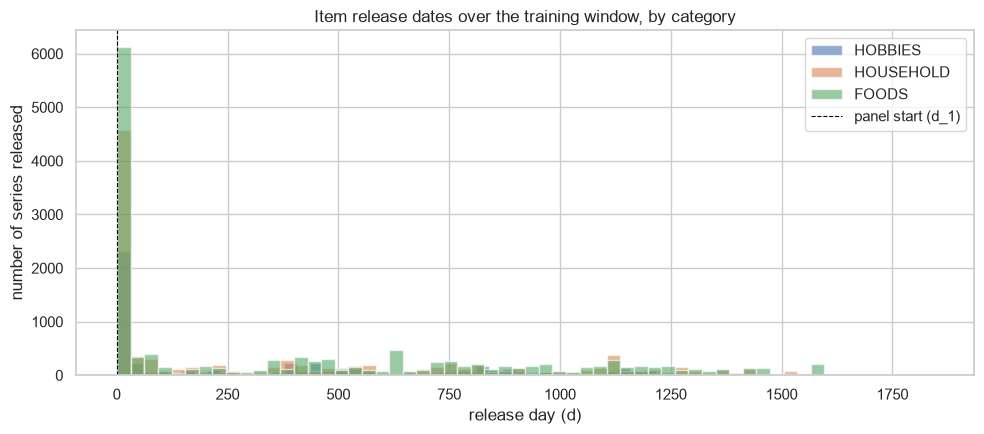

series present from d_1 (panel start): 10,932 (35.9%)
series released after d_1 ("new" items joining mid-panel): 19,558 (64.1%)


,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
HOBBIES,5650.0,384.321239,437.311090,1.0,1.0,211.0,757.0,1737.0
HOUSEHOLD,10470.0,386.844413,470.232440,1.0,1.0,92.0,750.0,1842.0
FOODS,14370.0,425.067989,493.635915,1.0,1.0,190.0,785.0,1842.0


In [3]:
release_day = sales_long.groupby("id", observed=True)["d"].min().rename("release_day")
release_cat = (
    sales_long[["id", "cat_id"]]
    .drop_duplicates("id")
    .set_index("id")["cat_id"]
)
release_df = release_day.to_frame().join(release_cat)

fig, ax = plt.subplots(figsize=(10, 4.5))
for cat, grp in release_df.groupby("cat_id", observed=True):
    ax.hist(grp["release_day"], bins=60, alpha=0.6, label=cat)
ax.axvline(1, color="black", lw=0.8, ls="--", label="panel start (d_1)")
ax.set_xlabel("release day (d)")
ax.set_ylabel("number of series released")
ax.set_title("Item release dates over the training window, by category")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lifecycle_release_dates.png", dpi=150)
plt.show()

n_at_panel_start = (release_df["release_day"] == 1).sum()
print(f"series present from d_1 (panel start): {n_at_panel_start:,} ({n_at_panel_start / len(release_df):.1%})")
print(f"series released after d_1 (\"new\" items joining mid-panel): "
      f"{(release_df['release_day'] > 1).sum():,} ({(release_df['release_day'] > 1).mean():.1%})")
release_df.groupby("cat_id", observed=True)["release_day"].describe()

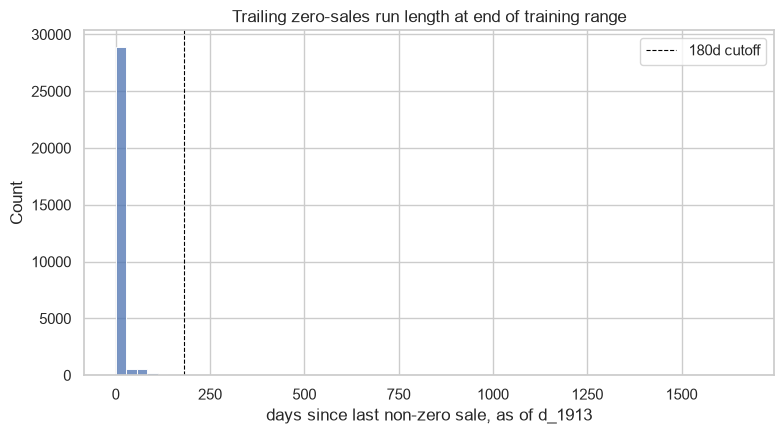

series with >=180d of trailing zero sales as of d_1913 ("functionally discontinued" but still in the panel): 173 (0.6%)
series with a sale in the final 28 days (d_1886-d_1913): 94.8%


In [4]:
TRAIN_LAST_DAY = 1913

last_nonzero_day = (
    sales_long.loc[sales_long["sales"] > 0]
    .groupby("id", observed=True)["d"]
    .max()
    .rename("last_nonzero_day")
)

lifecycle_df = release_df.join(last_nonzero_day)
# no all-zero series exist (confirmed in the Intermittency section), but guard anyway: an
# all-zero series would have no last_nonzero_day, so its "dormant" tail is its whole history.
lifecycle_df["last_nonzero_day"] = lifecycle_df["last_nonzero_day"].fillna(lifecycle_df["release_day"] - 1)
lifecycle_df["trailing_zero_days"] = TRAIN_LAST_DAY - lifecycle_df["last_nonzero_day"]

DORMANT_CUTOFF = 180  # ~6 months with zero sales, still structurally in the panel

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(lifecycle_df["trailing_zero_days"], bins=60, ax=ax)
ax.axvline(DORMANT_CUTOFF, color="black", lw=0.8, ls="--", label=f"{DORMANT_CUTOFF}d cutoff")
ax.set_xlabel("days since last non-zero sale, as of d_1913")
ax.set_title("Trailing zero-sales run length at end of training range")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lifecycle_trailing_zero_run.png", dpi=150)
plt.show()

n_dormant = (lifecycle_df["trailing_zero_days"] >= DORMANT_CUTOFF).sum()
print(f"series with >={DORMANT_CUTOFF}d of trailing zero sales as of d_1913 "
      f"(\"functionally discontinued\" but still in the panel): {n_dormant:,} "
      f"({n_dormant / len(lifecycle_df):.1%})")
print(f"series with a sale in the final 28 days (d_1886-d_1913): "
      f"{(lifecycle_df['trailing_zero_days'] < 28).mean():.1%}")

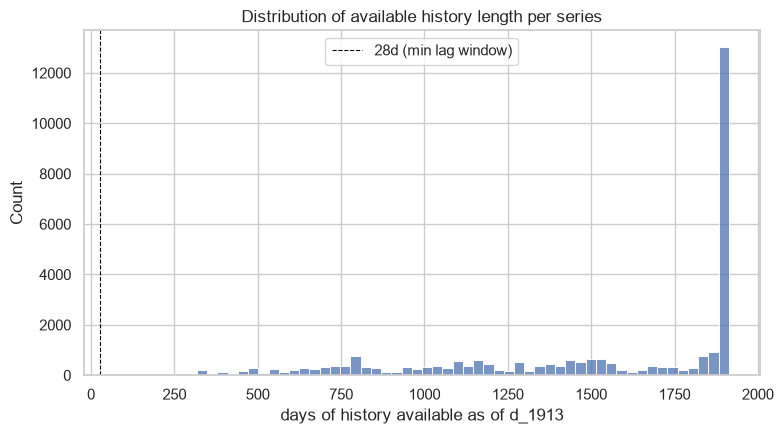

series with <28 days of history (no lag-28+ feature is computable at all, invariant 2): 0 (0.00%)
series with <90 days of history: 11 (0.04%)
series with <365 days of history: 415 (1.36%)


In [5]:
lifecycle_df["history_days"] = TRAIN_LAST_DAY - lifecycle_df["release_day"] + 1

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(lifecycle_df["history_days"], bins=60, ax=ax)
ax.axvline(28, color="black", lw=0.8, ls="--", label="28d (min lag window)")
ax.set_xlabel("days of history available as of d_1913")
ax.set_title("Distribution of available history length per series")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lifecycle_history_length.png", dpi=150)
plt.show()

print(f"series with <28 days of history (no lag-28+ feature is computable at all, invariant 2): "
      f"{(lifecycle_df['history_days'] < 28).sum():,} ({(lifecycle_df['history_days'] < 28).mean():.2%})")
print(f"series with <90 days of history: "
      f"{(lifecycle_df['history_days'] < 90).sum():,} ({(lifecycle_df['history_days'] < 90).mean():.2%})")
print(f"series with <365 days of history: "
      f"{(lifecycle_df['history_days'] < 365).sum():,} ({(lifecycle_df['history_days'] < 365).mean():.2%})")

**Interpretation.**

Only 35.9% of series were present at panel start (`d_1`); the other 64.1% joined mid-panel,
matching the assortment-growth story from the Trend section (active series +152.9% over the
training window) - this wasn't a handful of new SKUs, it's the majority of the catalog arriving
after the panel began. Release dates skew fairly even across categories rather than clustering
in one launch wave (median release day 92-211 depending on category), so this looks like ongoing
gradual assortment expansion, not a small number of large batch launches.

The "dies mid-panel" question resolved cleanly: since no series ever drops out of `sales_long`
(confirmed above), only **0.6% of series (173)** show a long dormant tail (>=180 days with zero
sales heading into `d_1913`), and 94.8% of series had at least one sale in the final 28 days. So
discontinuation, to the extent it exists in this window, is rare - most of the catalog is still
actively selling as training ends.

Cold-start is a non-issue at the invariant-2 boundary specifically: **zero series have less than
28 days of history**, so every series can support a lag-28 feature by construction (P1's release
trimming plus the training window length guarantees this). It only becomes a real practical
concern further out - 1.36% of series (415) have under a year of history, which matters for any
feature relying on the annual seasonal component (MSTL's `period=365`, used throughout this
notebook) rather than the lag features themselves.

**Feature implication:**
- A `days_since_release` (or `history_days`) feature is worth carrying - it's cheap, always
  defined, and flags the ~1.4% of series where annual-seasonality-based features are unreliable
  due to short history.
- The 173 dormant series (0.6%) are too small a group to need a dedicated "discontinued" model
  path, but a `days_since_last_sale` feature would let a single model down-weight or flag them
  naturally rather than needing separate routing (unlike the intermittency quadrants, which are
  large enough groups to justify routing).
- No cold-start exception is needed for lag-28+ features themselves - invariant 2's lag window is
  satisfied for every series in this dataset.

## Outliers

We flag extreme single-day spikes per series using a **per-series IQR fence on non-zero sales
days** (`Q1`/`Q3` computed only from days the series actually sold, since zero-inflation would
otherwise collapse the quartiles toward 0): `upper_fence = Q3 + 1.5 * (Q3 - Q1)`, spike =
`sales > upper_fence`. IQR was chosen over a MAD-based z-score: a z-score's "how many deviations
away" interpretation leans on a roughly-symmetric, near-normal shape, while non-zero demand here
is often right-skewed (occasional large multiples of the typical sale is exactly the phenomenon
being investigated) - IQR is quantile-based and doesn't carry that assumption.

To distinguish genuine promotional demand from unexplained (and potentially implausible) spikes,
each flagged day is cross-checked against three signals already computed earlier in this
notebook: a price drop (`relative_price < 0.90`, from the Price section), a named event day, and
a SNAP day (matched to the row's own `state_id`). A spike that coincides with one of these has a
known demand driver; one that doesn't is "unexplained" by the signals available in this dataset -
not necessarily wrong, just unaccounted for by what we can check.

spike days: 1,008,763 (2.192% of all rows)


series with >=1 spike day: 30,318 (99.4% of all series)


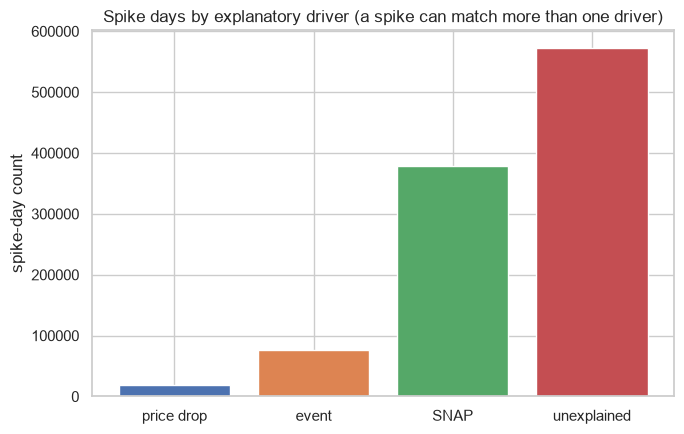


explained: 436,081 (43.2%)
unexplained: 572,682 (56.8%)


price drop      18500
event           76817
SNAP           378445
unexplained    572682
dtype: int64

In [7]:
nonzero_sales = sales_long.loc[sales_long["sales"] > 0, ["id", "sales"]]
q1 = nonzero_sales.groupby("id", observed=True)["sales"].quantile(0.25).rename("q1")
q3 = nonzero_sales.groupby("id", observed=True)["sales"].quantile(0.75).rename("q3")
fence_df = pd.concat([q1, q3], axis=1)
fence_df["iqr"] = fence_df["q3"] - fence_df["q1"]
fence_df["upper_fence"] = (fence_df["q3"] + 1.5 * fence_df["iqr"]).astype("float32")

sales_long = sales_long.merge(fence_df[["upper_fence"]], on="id", how="left")
sales_long["is_spike"] = sales_long["sales"] > sales_long["upper_fence"]

n_spike_days = sales_long["is_spike"].sum()
n_series_with_spike = sales_long.loc[sales_long["is_spike"], "id"].nunique()
print(f"spike days: {n_spike_days:,} ({n_spike_days / len(sales_long):.3%} of all rows)")
print(f"series with >=1 spike day: {n_series_with_spike:,} "
      f"({n_series_with_spike / sales_long['id'].nunique():.1%} of all series)")

spike_days = sales_long.loc[sales_long["is_spike"], [
    "id", "item_id", "store_id", "state_id", "date", "wm_yr_wk", "sales", "upper_fence",
    "event_name_1", "snap_CA", "snap_TX", "snap_WI",
]].copy()

# reuse the Price section's relative-price signal (item_id/store_id/wm_yr_wk grain)
spike_days = spike_days.merge(
    weekly_price_sorted[["item_id", "store_id", "wm_yr_wk", "relative_price"]],
    on=["item_id", "store_id", "wm_yr_wk"], how="left",
)
spike_days["is_price_drop"] = spike_days["relative_price"] < 0.90
spike_days["is_event"] = spike_days["event_name_1"].notna()

snap_lookup = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}
spike_days["is_snap"] = spike_days.apply(lambda r: r[snap_lookup[r["state_id"]]] == 1, axis=1)
spike_days["explained"] = (
    spike_days["is_price_drop"].fillna(False) | spike_days["is_event"] | spike_days["is_snap"]
)
spike_days["magnitude"] = spike_days["sales"] / spike_days["upper_fence"]

driver_counts = pd.Series({
    "price drop": spike_days["is_price_drop"].sum(),
    "event": spike_days["is_event"].sum(),
    "SNAP": spike_days["is_snap"].sum(),
    "unexplained": (~spike_days["explained"]).sum(),
})

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(driver_counts.index, driver_counts.values, color=["C0", "C1", "C2", "C3"])
ax.set_title("Spike days by explanatory driver (a spike can match more than one driver)")
ax.set_ylabel("spike-day count")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "outliers_spike_drivers.png", dpi=150)
plt.show()

print(f"\nexplained: {spike_days['explained'].sum():,} ({spike_days['explained'].mean():.1%})")
print(f"unexplained: {(~spike_days['explained']).sum():,} ({(~spike_days['explained']).mean():.1%})")
driver_counts

magnitude > 5x fence: 3,329 days (0.330% of spikes, 0.0072% of all rows)
magnitude > 10x fence: 274 days (0.027% of spikes, 0.0006% of all rows)
magnitude > 20x fence: 28 days (0.003% of spikes, 0.0001% of all rows)
magnitude > 50x fence: 4 days (0.000% of spikes, 0.0000% of all rows)



series with any spike >10x fence: 193 (0.63% of all series)


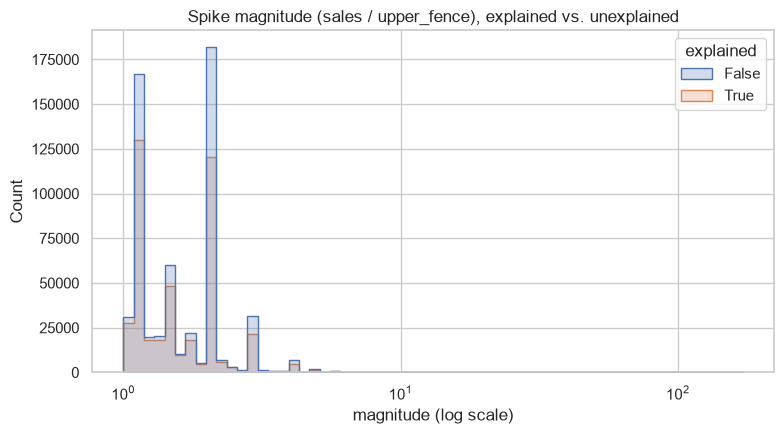


top 10 most extreme spikes:


,id,date,sales,upper_fence,magnitude,explained
426506,HOUSEHOLD_2_062_TX_1_evaluation,2013-06-05,601,3.5,171.714279,True
715946,HOUSEHOLD_2_239_CA_4_evaluation,2014-12-17,300,3.5,85.714287,False
676787,HOUSEHOLD_1_133_CA_1_evaluation,2014-10-02,239,3.5,68.285713,True
50427,FOODS_2_285_TX_1_evaluation,2011-05-06,634,12.0,52.833332,True
918096,HOUSEHOLD_2_239_CA_4_evaluation,2015-12-09,162,3.5,46.285713,True
706169,HOBBIES_2_100_CA_1_evaluation,2014-11-29,34,1.0,34.000000,False
378838,FOODS_3_169_TX_1_evaluation,2013-03-04,103,3.5,29.428572,False
452925,HOUSEHOLD_1_474_TX_2_evaluation,2013-07-24,626,21.5,29.116280,False
806144,HOUSEHOLD_2_314_TX_1_evaluation,2015-06-05,29,1.0,29.000000,True
227542,FOODS_3_098_TX_3_evaluation,2012-05-18,100,3.5,28.571428,False


In [8]:
for cutoff in [5, 10, 20, 50]:
    n = (spike_days["magnitude"] > cutoff).sum()
    print(f"magnitude > {cutoff}x fence: {n:,} days ({n / len(spike_days):.3%} of spikes, "
          f"{n / len(sales_long):.4%} of all rows)")

n_series_extreme = spike_days.loc[spike_days["magnitude"] > 10, "id"].nunique()
print(f"\nseries with any spike >10x fence: {n_series_extreme:,} "
      f"({n_series_extreme / sales_long['id'].nunique():.2%} of all series)")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(
    data=spike_days, x="magnitude", hue="explained", bins=60, log_scale=(True, False),
    element="step", ax=ax,
)
ax.set_title("Spike magnitude (sales / upper_fence), explained vs. unexplained")
ax.set_xlabel("magnitude (log scale)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "outliers_magnitude_distribution.png", dpi=150)
plt.show()

print("\ntop 10 most extreme spikes:")
spike_days.nlargest(10, "magnitude")[["id", "date", "sales", "upper_fence", "magnitude", "explained"]]

**Interpretation and outlier-handling policy.**

IQR-flagged spikes are common (2.19% of all series-days; 99.4% of series have at least one over
their history) but almost all of them are mild: median magnitude is only ~1.45x the fence, and
75% are under 2x. Only 274 days (0.0006% of all rows, across 193 of 30,490 series) exceed 10x the
fence, and the 10 most extreme cases are large-but-plausible integer sales counts (e.g. 601 units
on an item whose typical non-zero day tops out around 3-4) - not fractional values, negative
values, or other signatures of a data error, which P1's hygiene checks already screened for
separately.

43.2% of spikes align with a known driver already in this dataset (mostly SNAP: 378k of the 436k
explained spikes, vs. 76.8k for events and only 18.5k for price drops - consistent with the Price
section's finding that promotional price cuts are rare). The remaining 56.8% are "unexplained,"
but given how mild most spike magnitudes are, this is best read as ordinary right-skewed demand
variability that our three known signals don't fully capture (weather, local store-level
promotions not reflected in `sell_price`, restocking timing) - not evidence of bad data.

**Policy: do not clip or winsorize the training target.** Rationale:
1. The brief's own warning applies directly - clipping would improve in-sample RMSSE while
   discarding real demand signal the model needs to learn to predict occasional large days.
2. The extreme tail (>10x fence) is negligible in volume (0.0006% of rows) and plausible in
   magnitude, so there's no clear evidence of measurement error to justify correcting values,
   as opposed to genuine but rare demand.
3. A large share of spikes already have a known, model-usable driver (SNAP/event/price-drop
   flags carried from earlier sections) - the fix for "the model doesn't see this coming" is
   better features, not target manipulation.

**Feature implication:** carry the SNAP/event/price-drop flags already built (this is mostly a
restatement of what SNAP, Events, and Price already justified) so the model has a chance to
anticipate the 43% of spikes that are predictable; for the unexplained majority, no additional
feature is proposed here beyond what those sections already produced - accept the residual
variance rather than engineering around it. If a specific series' RMSSE later turns out to be
dominated by an unexplained spike, that's a case for a per-series review at the modeling phase,
not a blanket EDA-stage correction.

## Hypothesis table

Gate deliverable: every plot in this notebook either kills or justifies a candidate feature for
P5. This table is the roll-up.

| # | Finding | Evidence | Proposed feature | Verdict |
|---|---|---|---|---|
| 1 | Raw trend (+81.3%) is mostly assortment growth (active series +152.9%); units per active series actually fell -36.7% | fig `trend_assortment.png` | Reject a raw-total trend/momentum feature; adopt one normalized against active-catalog size instead | reject (raw) / adopt (normalized) |
| 2 | Weekend lift is real in every category but modest and fairly uniform (HOUSEHOLD +0.33, FOODS +0.28, HOBBIES +0.24 pct pts of trend) | fig `seasonality_dow_mstl.png` | Per-category day-of-week / weekend dummy | adopt |
| 3 | Annual seasonal swing differs sharply by category: HOUSEHOLD (0.19 pct pts, Aug peak/Dec trough) is ~1.7x FOODS/HOBBIES (0.11) | fig `seasonality_month_mstl.png` | Per-category month-of-year / annual-harmonic feature, not pooled | adopt |
| 4 | FOODS SNAP lift is state-specific and varies ~10x: WI +2.5, TX +2.0, CA +0.2 pct pts of trend | fig `snap_lift_by_state.png` | Per-state SNAP flag matched to series `state_id` (not a single pooled `is_snap_day`) | adopt |
| 5 | Closure holidays (Christmas -11.9%, Thanksgiving -8.4%, Easter -8.4%) dip on the day with a lead-up lift beforehand (Thanksgiving +15.1%); open-store federal holidays (Labor Day +12.5%) lift instead | fig `events_headline_phases.png` | Per-`event_name` dummy plus explicit lead-up/hangover offset dummies for the closure-holiday group | adopt |
| 6 | Pooling by `event_type` nearly cancels the signal (`National` mean ~+0.2%, mixing dipping and lifting holidays) | fig `events_by_type.png` | A single pooled `event_type` feature | reject |
| 7 | Price changes are rare: median 0.7% of weeks change, 27.5% of series never change price, median gap ~91 weeks between changes | fig `price_change_frequency.png` | A price-change-recency / "still at original price" structural-break flag | adopt |
| 8 | Sales response to a price change is noise-dominated at the pooled level (Spearman corr with normalized sales: raw price -0.028, relative-to-baseline price +0.024 - both near zero, one sign-flipped) | fig `price_change_sales_response.png` | A pooled cross-sectional price-elasticity coefficient | reject |
| 9 | 91% of series fall in the sparse ADI/CV² quadrants (intermittent 72.7%, lumpy 18.4%); only 6.1% are smooth | fig `intermittency_adi_cv2_quadrants.png` | Segment label from `series_segments.parquet` used for model routing (esp. isolating the 18.4% lumpy group) | adopt |
| 10 | Median series is zero-sales on 63.5% of days - mean/std-based statistics are unstable at this zero-inflation level | fig `intermittency_zero_fraction.png` | Any per-series scaling/normalization feature should use robust statistics (median/MAD or non-zero-conditional), not mean/std; favors a zero-inflated/Tweedie-style model objective | adopt |
| 11 | 64.1% of series joined the panel after `d_1` (only 35.9% present at panel start), matching the assortment-growth finding at the item level | fig `lifecycle_release_dates.png` | `days_since_release` / `history_days` feature | adopt |
| 12 | Only 0.6% of series (173) show a long dormant tail (>=180d trailing zero sales); no series ever drops out of the panel | fig `lifecycle_trailing_zero_run.png` | `days_since_last_sale` feature; a dedicated "discontinued series" model path | adopt (feature) / reject (dedicated path - group too small) |
| 13 | 0 series have <28 days of history (lag-28 always computable); 1.36% have <365 days, affecting annual-seasonal feature reliability | fig `lifecycle_history_length.png` | `history_days` used to gate/down-weight annual-seasonality features for short-history series | adopt |
| 14 | IQR-flagged spikes are common but almost all mild (median 1.45x fence); the extreme tail (>10x, 274 days / 0.0006% of rows) is plausible in magnitude, not a data-error signature; 43.2% of spikes align with an existing SNAP/event/price-drop flag | figs `outliers_spike_drivers.png`, `outliers_magnitude_distribution.png` | Clip/winsorize the training target for spikes | reject (see `DECISIONS.md` for the full policy) |

14 rows, target of >=10 met. Full policy rationale for row 14 is in `DECISIONS.md` rather than
repeated here, per the brief's "Decide the handling policy here and record it in DECISIONS.md."